In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.signal import welch, find_peaks
import os

from funciones.cargador import obtener_una_muestra, DATA_DIR, TARGET_NOISE

In [2]:
def detector_cicloestacionario_rapido(iq_tensor: torch.Tensor, fs: float = 14e6, nperseg: int = 4096):
    """
    Detector de características cicloestacionarias optimizado para grandes tensores I/Q.
    Aplica una transformación no lineal para revelar frecuencias cíclicas (tasas de símbolo/OFDM).
    
    Args:
        iq_tensor: Tensor PyTorch [2, N].
        fs: Frecuencia de muestreo (14 MHz).
        nperseg: Resolución espectral (mayor = más resolución cíclica, menor = más promediado de ruido).
        
    Returns:
        dict: Frecuencias cíclicas (alphas), espectro cíclico y picos detectados.
    """
    # 1. Extracción y conversión a complejo
    i_np = iq_tensor[0].numpy()
    q_np = iq_tensor[1].numpy()
    signal_complex = i_np + 1j * q_np
    
    # 2. Transformación No Lineal (Regeneración de portadora/tasa de símbolos)
    # Al calcular la magnitud al cuadrado |x(t)|^2, exponemos las periodicidades de la envolvente
    # ocultas por la modulación digital, independientemente de la fase.
    z_t = np.abs(signal_complex)**2
    
    # Normalización para evitar desbordamientos numéricos
    z_t = z_t - np.mean(z_t)
    
    # 3. Estimación del Espectro de Frecuencias Cíclicas (Perfil alfa en tau=0)
    # Usamos el método de Welch para promediar el ruido y destacar los picos deterministas
    alphas, cyclic_spectrum = welch(z_t, fs=fs, nperseg=nperseg, window='hann', return_onesided=True)
    
    # Convertimos a dB para mejor visualización y cálculo de umbrales
    cyclic_spectrum_db = 10 * np.log10(cyclic_spectrum + 1e-12)
    
    # 4. Detección de picos cíclicos (Omitimos el DC en alpha=0)
    # Excluimos los primeros bins que concentran la energía residual
    offset_dc = 5 
    
    # Calculamos un umbral dinámico basado en la estadística del piso de ruido del espectro cíclico
    piso_ruido = np.median(cyclic_spectrum_db[offset_dc:])
    std_ruido = np.std(cyclic_spectrum_db[offset_dc:])
    umbral_cfar = piso_ruido + (6 * std_ruido) # Seis sigmas por encima de la mediana
    
    picos_idx, _ = find_peaks(cyclic_spectrum_db[offset_dc:], height=umbral_cfar, distance=10)
    picos_idx += offset_dc # Ajustamos el índice real
    
    # Liberar memoria
    del i_np, q_np, signal_complex, z_t
    
    return {
        "alphas": alphas,
        "espectro": cyclic_spectrum_db,
        "picos_idx": picos_idx,
        "umbral": umbral_cfar
    }

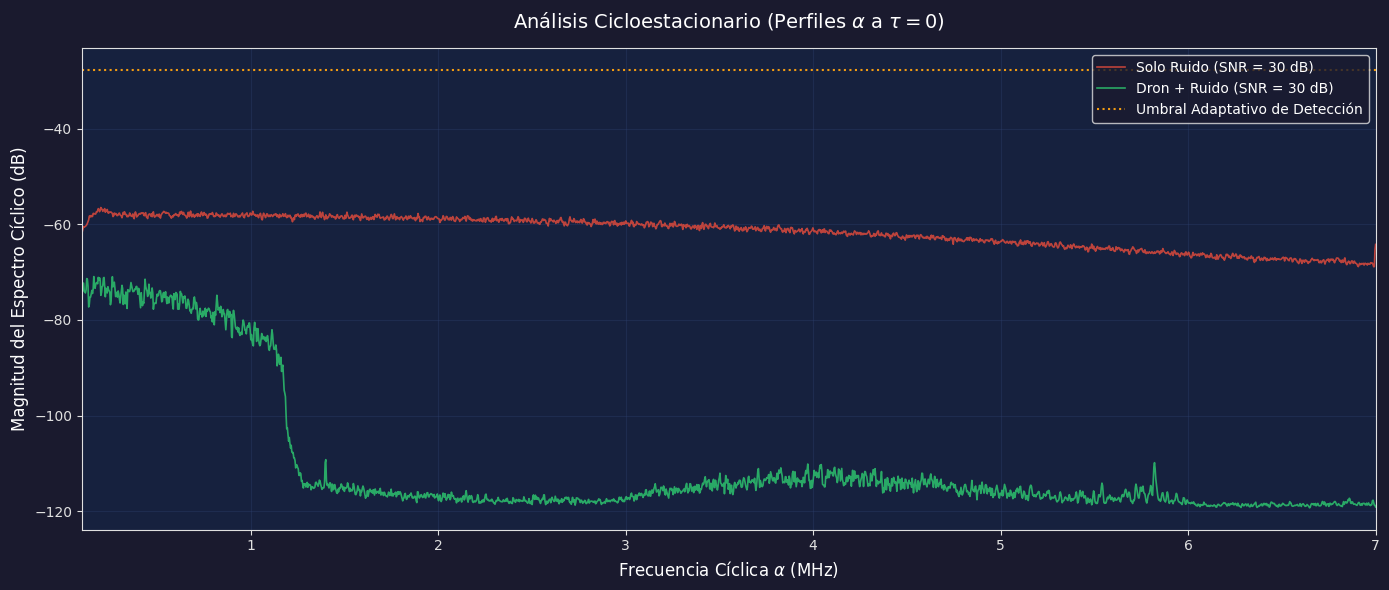

In [3]:
SNR_PRUEBA = 30
TARGET_DRON = 0 # DJI
FS = 14e6

# Cargamos dos muestras: Ruido puro y Dron sumergido en ruido
iq_ruido, _, _, _ = obtener_una_muestra(DATA_DIR, target=TARGET_NOISE, snr=SNR_PRUEBA, index=0)
iq_dron, _, _, _ = obtener_una_muestra(DATA_DIR, target=TARGET_DRON, snr=SNR_PRUEBA, index=1)

# Ejecutamos el detector cicloestacionario
res_ruido = detector_cicloestacionario_rapido(iq_ruido, fs=FS)
res_dron = detector_cicloestacionario_rapido(iq_dron, fs=FS)

# ==============================================================================
# Visualización Profesional SIGINT
# ==============================================================================
plt.figure(figsize=(14, 6), facecolor='#1a1a2e')
ax = plt.gca()
ax.set_facecolor('#16213e')
ax.tick_params(colors='#e0e0e0')
for spine in ax.spines.values(): spine.set_color('#e0e0e0')

# Espectro del ruido
plt.plot(res_ruido["alphas"] / 1e6, res_ruido["espectro"], color='#e74c3c', alpha=0.8, linewidth=1.2, label=f'Solo Ruido (SNR = {SNR_PRUEBA} dB)')

# Espectro del Dron
plt.plot(res_dron["alphas"] / 1e6, res_dron["espectro"], color='#2ecc71', alpha=0.8, linewidth=1.2, label=f'Dron + Ruido (SNR = {SNR_PRUEBA} dB)')

# Marcar picos detectados en el dron
if len(res_dron["picos_idx"]) > 0:
    alphas_picos = res_dron["alphas"][res_dron["picos_idx"]] / 1e6
    amps_picos = res_dron["espectro"][res_dron["picos_idx"]]
    plt.scatter(alphas_picos, amps_picos, color='#f1c40f', s=50, zorder=5, label='Frecuencias Cíclicas Detectadas (Firmas)')

# Línea de umbral CFAR del Dron
plt.axhline(y=res_dron["umbral"], color='#f39c12', linestyle=':', linewidth=1.5, label='Umbral Adaptativo de Detección')

plt.title(f'Análisis Cicloestacionario (Perfiles $\\alpha$ a $\\tau=0$)', color='white', fontsize=14, pad=15)
plt.xlabel('Frecuencia Cíclica $\\alpha$ (MHz)', color='white', fontsize=12)
plt.ylabel('Magnitud del Espectro Cíclico (dB)', color='white', fontsize=12)
plt.legend(facecolor='#1a1a2e', edgecolor='#e0e0e0', labelcolor='white', loc='upper right')
plt.grid(color='#2c3e6b', alpha=0.4)

# Limitamos el eje X para ignorar el pico de continua (DC) que domina la gráfica
plt.xlim(0.1, FS / 2 / 1e6) 

plt.tight_layout()
plt.show()